# 01 - Data Quality Overview

**Milestone 1 — Part 2.A**: Load the Zillow housing dataset and perform a comprehensive data quality assessment.

## Objectives
- Download / load the dataset into a DataFrame
- Examine shape, dtypes, and column names
- Assess missing-value percentages per feature
- Count unique values per feature
- Identify categorical vs numerical features
- Flag obviously useless features (first impressions)

## Expected Outcomes
| Deliverable | Description |
|---|---|
| `df` (raw) | The unmodified DataFrame loaded from CSV |
| Missing-value table | A summary table with `% missing` for every column |
| Unique-value table | `nunique()` for every column |
| Feature-type classification | Categorical vs numerical labels |
| Initial drop candidates | List of features that look useless at first glance |

## Mapping to Milestone 1
- **Part 2.A** — Load data, `.head()`, `.info()`, `.nunique()`, answer discussion questions 2.A.1–2.A.4

---

In [40]:
# =============================
# Imports
# =============================
import os
import requests
import numpy as np
import pandas as pd
from IPython.display import display
from urllib.parse import urlparse

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42

## 1. Download and Load the Dataset

In [41]:
url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"
filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    print("Downloading …")
    response = requests.get(url)
    response.raise_for_status()
    with open(filename, "wb") as f:
        f.write(response.content)
    print("Done.")
else:
    print("File already exists — skipping download.")

df = pd.read_csv(filename)
print(f"Shape: {df.shape}")

File already exists — skipping download.
Shape: (77613, 55)


## 2. First Look — `.head()`, `.info()`, `.describe()`

In [42]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [52]:
info_df = pd.DataFrame({
    "non_null": df.notnull().sum(),
    "null": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "nunique": df.nunique(),
     "dtype": df.dtypes,
})
display(info_df)
print(f"\nShape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Dtypes: {dict(df.dtypes.value_counts())}")

,non_null,null,null_pct,nunique,dtype
parcelid,77613,0,0.00,77414,int64
airconditioningtypeid,25007,52606,67.78,5,float64
architecturalstyletypeid,207,77406,99.73,5,float64
basementsqft,50,77563,99.94,43,float64
bathroomcnt,77579,34,0.04,22,float64
bedroomcnt,77579,34,0.04,16,float64
buildingclasstypeid,15,77598,99.98,2,float64
buildingqualitytypeid,49809,27804,35.82,12,float64
calculatedbathnbr,76963,650,0.84,21,float64
decktypeid,614,76999,99.21,1,float64



Shape: (77613, 55)
Memory: 47.3 MB
Dtypes: {dtype('float64'): 49, dtype('O'): 5, dtype('int64'): 1}


In [44]:
desc = df.describe().T
desc["skew"] = df.skew(numeric_only=True)
desc["skewed"] = desc["skew"].apply(lambda s: "YES" if abs(s) > 1 else "moderate" if abs(s) > 0.5 else "no")

display(desc.style.map(
    lambda v: "background-color: #ffcccc" if v == "YES"
              else "background-color: #fff3cd" if v == "moderate"
              else "",
    subset=["skewed"]
))

,count,mean,std,min,25%,50%,75%,max,skew,skewed
parcelid,77613.000000,13007807.003633,3518717.006869,10711855.000000,11538209.000000,12530044.000000,14211010.000000,167689317.000000,32.673124,YES
airconditioningtypeid,25007.000000,1.812013,2.965768,1.000000,1.000000,1.000000,1.000000,13.000000,3.448640,YES
architecturalstyletypeid,207.000000,7.386473,2.728030,2.000000,7.000000,7.000000,7.000000,21.000000,4.012802,YES
basementsqft,50.000000,679.720000,689.703546,38.000000,273.000000,515.000000,796.500000,3560.000000,2.616164,YES
bathroomcnt,77579.000000,2.298496,0.996732,0.000000,2.000000,2.000000,3.000000,18.000000,1.288251,YES
bedroomcnt,77579.000000,3.053223,1.140480,0.000000,2.000000,3.000000,4.000000,16.000000,0.767899,moderate
buildingclasstypeid,15.000000,3.933333,0.258199,3.000000,4.000000,4.000000,4.000000,4.000000,-3.872983,YES
buildingqualitytypeid,49809.000000,6.533779,1.722062,1.000000,6.000000,6.000000,8.000000,12.000000,0.048043,no
calculatedbathnbr,76963.000000,2.316392,0.979689,1.000000,2.000000,2.000000,3.000000,18.000000,1.412816,YES
decktypeid,614.000000,66.000000,0.000000,66.000000,66.000000,66.000000,66.000000,66.000000,0.000000,no


- **Target** (`taxvaluedollarcnt`): range $1K–$49M, mean ~$490K vs median ~$359K — heavily right-skewed, outlier removal will be important in notebook 03
- **`roomcnt`**: 75th percentile is **0.0** — most values are zero, which is suspicious for "total room count" and suggests data quality issues or a different definition
- **`decktypeid`**: std = 0.0, all non-null values are 66 — a constant, confirmed later in the zero-variance analysis
- **`lotsizesquarefeet`**: max ~7M vs median ~7,200 — extreme outliers exist (1000x the median)
- **`bathroomcnt`**: max = 18, `bedroomcnt` max = 16 — potential outliers worth investigating in notebook 02

## 3. Missing-Value Assessment

In [45]:
def missing_value_summary(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame with count and percentage of missing values per column."""
    total = dataframe.isnull().sum()
    pct = (total / len(dataframe)) * 100
    summary = pd.DataFrame({"missing_count": total, "missing_pct": pct})
    return summary.sort_values("missing_pct", ascending=False)

missing_df = missing_value_summary(df)
missing_df

,missing_count,missing_pct
buildingclasstypeid,77598,99.980673
finishedsquarefeet13,77571,99.945885
storytypeid,77563,99.935578
basementsqft,77563,99.935578
yardbuildingsqft26,77543,99.909809
fireplaceflag,77441,99.778388
architecturalstyletypeid,77406,99.733292
typeconstructiontypeid,77390,99.712677
finishedsquarefeet6,77227,99.502661
pooltypeid10,77148,99.400874


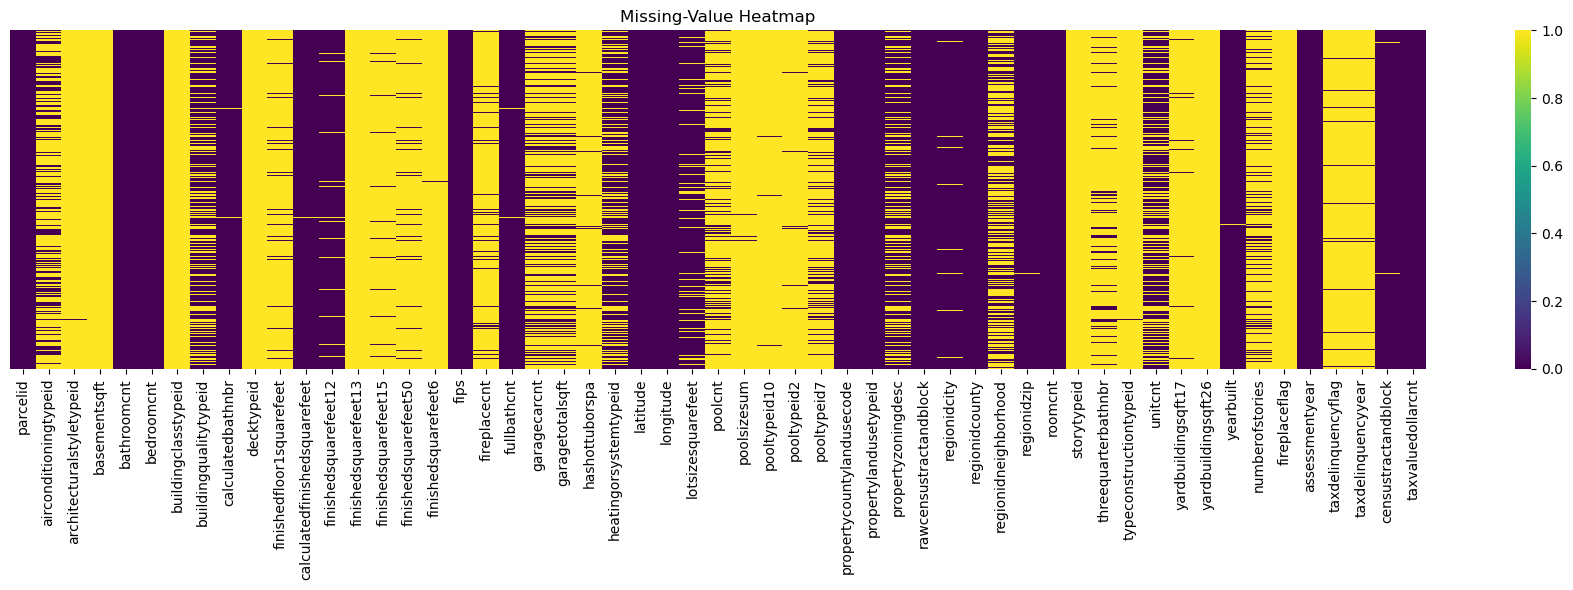

In [46]:
# TODO: Visualize missing-value heatmap (optional but helpful)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing-Value Heatmap")
plt.tight_layout()
plt.show()

## 4. Unique-Value Counts

In [47]:
unique_counts = df.nunique().sort_values(ascending=False)
unique_counts

parcelid                        77414
latitude                        64038
longitude                       62461
taxvaluedollarcnt               50949
rawcensustractandblock          39188
censustractandblock             39006
lotsizesquarefeet               18848
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
propertyzoningdesc               1907
finishedsquarefeet50             1807
finishedfloor1squarefeet         1787
finishedsquarefeet15             1724
garagetotalsqft                   839
yardbuildingsqft17                540
regionidneighborhood              480
regionidzip                       389
finishedsquarefeet6               350
poolsizesum                       262
regionidcity                      175
yearbuilt                         136
propertycountylandusecode          75
yardbuildingsqft26                 59
basementsqft                       43
bathroomcnt                        22
calculatedbathnbr                  21
bedroomcnt  

## 5. Feature Classification — Categorical vs Numerical

In [48]:
# Known categorical features
KNOWN_CATEGORICALS = [
    "airconditioningtypeid",
    "architecturalstyletypeid",
    "buildingclasstypeid",
    "decktypeid",
    "fips",
    "hashottuborspa",
    "heatingorsystemtypeid",
    "propertycountylandusecode",
    "propertylandusetypeid",
    "propertyzoningdesc",
    "regionidcity",
    "regionidcounty",
    "regionidneighborhood",
    "regionidzip",
    "storytypeid",
    "typeconstructiontypeid",
    "fireplaceflag",
    "taxdelinquencyflag",
]

def classify_features(dataframe: pd.DataFrame, known_categoricals: list = None, cat_threshold: int = 20) -> dict:
    """Classify columns as categorical or numerical.
    
    A column is treated as categorical if it is of object/category dtype
    or if its number of unique values is below `cat_threshold`.
    """
    if known_categoricals is None:
        known_categoricals = []
    categorical = []
    numerical = []
    for col in dataframe.columns:
        if col in known_categoricals or dataframe[col].dtype in ('object', 'category', 'bool'):
            categorical.append(col)
        else:
            numerical.append(col)
    return {"categorical": categorical, "numerical": numerical}

feature_types = classify_features(df , known_categoricals=KNOWN_CATEGORICALS)
print(f"Categorical ({len(feature_types['categorical'])}): {feature_types['categorical']}")
print(f"Numerical   ({len(feature_types['numerical'])}):  {feature_types['numerical']}")

Categorical (18): ['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'decktypeid', 'fips', 'hashottuborspa', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid', 'fireplaceflag', 'taxdelinquencyflag']
Numerical   (37):  ['parcelid', 'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'rawcensustractandblock', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt

## 6. Initial Assessment — Potentially Useless Features

Flag features that look useless at first glance based on:
- **Business logic** (e.g., `parcelid` is an identifier, not a predictor)
- **High missing %** (> 90 %)
- **Very low unique values** (e.g., only 1 unique value → zero variance)

In [49]:
# TODO: Fill in your assessment after reviewing the data above.
#
# Example starter logic — refine with your own domain reasoning:

HIGH_MISSING_THRESHOLD = 90  # percent
MISSING_THRESHOLD = 5.0  # percent — if >5% missing, the nullity pattern carries information

high_missing_cols = missing_df[missing_df["missing_pct"] > HIGH_MISSING_THRESHOLD].index.tolist()
binary_flag_cols = [
    col for col in df.columns
    if df[col].nunique() == 1 and (df[col].isnull().sum() / len(df)) * 100 > MISSING_THRESHOLD
]

true_zero_variance_cols = [
    col for col in df.columns
    if df[col].nunique() <= 1 and (df[col].isnull().sum() / len(df)) * 100 <= MISSING_THRESHOLD
]
id_cols = ["parcelid"]  # identifiers with no predictive value

print("High-missing (>90%):", high_missing_cols)
print("Binary flags (info is in null vs non-null):", binary_flag_cols)
print("True zero-variance (genuinely useless):    ", true_zero_variance_cols)
print("ID columns:         ", id_cols)

High-missing (>90%): ['buildingclasstypeid', 'finishedsquarefeet13', 'storytypeid', 'basementsqft', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedfloor1squarefeet']
Binary flags (info is in null vs non-null): ['decktypeid', 'hashottuborspa', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'fireplaceflag', 'taxdelinquencyflag']
True zero-variance (genuinely useless):     ['assessmentyear']
ID columns:          ['parcelid']


## 7. Redundant Feature Groups

Features that measure the same underlying property. Keeping all of them adds multicollinearity without new information.

In [50]:
redundant_groups = {
    "bathroom_variants": [
        "bathroomcnt", "calculatedbathnbr", "fullbathcnt", "threequarterbathnbr"
    ],
    "sqft_variants": [
        "calculatedfinishedsquarefeet", "finishedsquarefeet12",
        "finishedfloor1squarefeet", "finishedsquarefeet50",
        "finishedsquarefeet15", "finishedsquarefeet6", "finishedsquarefeet13"
    ],
    "pool_indicators": [
        "poolcnt", "pooltypeid7", "pooltypeid2", "pooltypeid10", "poolsizesum"
    ],
    "geographic_ids": [
        "rawcensustractandblock", "censustractandblock",
        "regionidcity", "regionidcounty", "regionidzip", "regionidneighborhood",
        "latitude", "longitude", "fips"
    ],
}

report_rows = []
for group_name, cols in redundant_groups.items():
    present = [c for c in cols if c in df.columns]
    if len(present) < 2:
        continue
    corr = df[present].corr()
    for i, col_a in enumerate(present):
        for col_b in present[i+1:]:
            r = corr.loc[col_a, col_b]
            report_rows.append({
                "group": group_name,
                "feature_a": col_a,
                "feature_b": col_b,
                "correlation": round(r, 3) if pd.notna(r) else None,
                "redundant": "YES" if pd.notna(r) and abs(r) > 0.95 else "no"
            })
redundancy_report = pd.DataFrame(report_rows)
display(redundancy_report.style.map(
    lambda v: "background-color: #ffcccc" if v == "YES" else "",
    subset=["redundant"]
))

,group,feature_a,feature_b,correlation,redundant
0,bathroom_variants,bathroomcnt,calculatedbathnbr,1.000000,YES
1,bathroom_variants,bathroomcnt,fullbathcnt,0.984000,YES
2,bathroom_variants,bathroomcnt,threequarterbathnbr,0.196000,no
3,bathroom_variants,calculatedbathnbr,fullbathcnt,0.984000,YES
4,bathroom_variants,calculatedbathnbr,threequarterbathnbr,0.196000,no
5,bathroom_variants,fullbathcnt,threequarterbathnbr,0.133000,no
6,sqft_variants,calculatedfinishedsquarefeet,finishedsquarefeet12,1.000000,YES
7,sqft_variants,calculatedfinishedsquarefeet,finishedfloor1squarefeet,0.728000,no
8,sqft_variants,calculatedfinishedsquarefeet,finishedsquarefeet50,0.713000,no
9,sqft_variants,calculatedfinishedsquarefeet,finishedsquarefeet15,1.000000,YES


## Summary

Of 55 total features in the dataset:
- **20** have >90% missing values (strong drop candidates)
- **1** is true zero-variance (`assessmentyear` — all values are 2016)
- **9** are binary-flag columns (information is in null vs non-null, not the value itself)
- **11** redundant pairs confirmed (|correlation| > 0.95) across bathroom, square footage, and geographic groups
- **1** is an identifier (`parcelid`) with no predictive value
- **~25** genuinely useful features remain for deeper EDA in the next notebook

---
## Discussion Questions (Milestone Part 2.A)

### 2.A.1 — Which features are categorical?

There are 18 categorical features. Although many are stored as float64 in the CSV, features like fips, regionidcounty, and heatingorsystemtypeid are lookup codes where the numeric value has no mathematical meaning — fips 6037 is not "greater than" 6059. The full list: airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, decktypeid, fips, hashottuborspa, heatingorsystemtypeid, propertycountylandusecode, propertylandusetypeid, propertyzoningdesc, regionidcity, regionidcounty, regionidneighborhood, regionidzip, storytypeid, typeconstructiontypeid, fireplaceflag, taxdelinquencyflag.


### 2.A.2 — Are there features that appear useless for the business purpose?

Parcelid is an arbitrary identifier with no predictive meaning. rawcensustractandblock and censustractandblock are raw geographic codes that largely overlap with the regionid* columns and fips, as confirmed by the redundancy analysis (correlation of 1.0 between rawcensustractandblock and fips). assessmentyear has a single value of 2016 across all rows, contributing zero variance. Beyond these, the redundancy report reveals that the 7 square-footage variants contain multiple pairs with >0.95 correlation, and the 4 bathroom columns show similar duplication — keeping all of them would introduce multicollinearity without new information.

### 2.A.3 — Are there features useless because of missing-value percentage?

Twenty features exceed 90% missing values. The most extreme cases — buildingclasstypeid (99.98%), finishedsquarefeet13 (99.95%), storytypeid (99.94%), and basementsqft (99.94%) — have fewer than 50 non-null values out of 77,613 rows, making any imputation strategy unreliable. A second tier (92–99% missing) includes finishedsquarefeet6, pooltypeid10, decktypeid, and poolsizesum. However, some high-missing columns like poolcnt and fireplaceflag are binary presence/absence flags where the nullity itself is the signal, so they should not be dismissed purely on missing percentage.

### 2.A.4 — Are there features useless because of unique-value count?

assessmentyear is the only truly zero-variance feature (all 77,579 non-null values are 2016). Nine columns appear to have just 1 unique value (decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, taxdelinquencyflag) but these are binary-flag columns where the single value (e.g., poolcnt = 1.0) indicates presence and NaN indicates absence. The information is encoded in nullity, not the value itself. For these, converting to a 0/1 has-feature column would recover useful signal. The decktypeid (all values = 66 when present, 99.2% null) is the least useful of this group given its extreme sparsity.

---

### Next Notebook → `02_eda_feature_visualization.ipynb`